In [37]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

df = pd.read_csv("data/dataset.csv")
df.head()

,player_id,competition,season,player,nation,position,squad,age,minutes,matches,starts,goals,assists,shots,shots_on_target,xg,npxg,xag
0,5f09991f,Premier League,2019-2020,Patrick van Aanholt,nlNED,DF,Crystal Palace,28,2507,29,29,3,2,0,0,2.1,1.3,3.7
1,774cf58b,Premier League,2019-2020,Max Aarons,engENG,DF,Norwich City,19,3240,36,36,0,1,0,0,0.6,0.6,3.9
2,f586779e,Premier League,2019-2020,Tammy Abraham,engENG,FW,Chelsea,21,2215,34,25,15,3,0,0,16.4,16.4,2.7
3,f2bf1b0f,Premier League,2019-2020,Che Adams,sctSCO,FW,Southampton,23,1111,30,12,4,2,0,0,5.3,5.3,1.7
4,f76e6b4e,Premier League,2019-2020,Adrián,esESP,GK,Liverpool,32,875,11,9,0,0,0,0,0.0,0.0,0.0


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2749 entries, 0 to 2748
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   player_id        2749 non-null   object 
 1   competition      2749 non-null   object 
 2   season           2749 non-null   object 
 3   player           2749 non-null   object 
 4   nation           2746 non-null   object 
 5   position         2749 non-null   object 
 6   squad            2749 non-null   object 
 7   age              2749 non-null   int64  
 8   minutes          2749 non-null   int64  
 9   matches          2749 non-null   int64  
 10  starts           2749 non-null   int64  
 11  goals            2749 non-null   int64  
 12  assists          2749 non-null   int64  
 13  shots            2749 non-null   int64  
 14  shots_on_target  2749 non-null   int64  
 15  xg               2749 non-null   float64
 16  npxg             2749 non-null   float64
 17  xag           

In [39]:
df.corr(numeric_only=True)

,age,minutes,matches,starts,goals,assists,shots,shots_on_target,xg,npxg,xag
age,1.000000,0.214363,0.194907,0.211689,0.038444,0.035996,NaN,NaN,0.041728,0.033280,0.043160
minutes,0.214363,1.000000,0.934977,0.996161,0.418245,0.469191,NaN,NaN,0.436257,0.441484,0.539726
matches,0.194907,0.934977,1.000000,0.922313,0.460067,0.505174,NaN,NaN,0.490229,0.504351,0.576655
starts,0.211689,0.996161,0.922313,1.000000,0.421718,0.473172,NaN,NaN,0.438071,0.443900,0.543036
goals,0.038444,0.418245,0.460067,0.421718,1.000000,0.576708,NaN,NaN,0.932301,0.913842,0.622810
assists,0.035996,0.469191,0.505174,0.473172,0.576708,1.000000,NaN,NaN,0.589199,0.586218,0.874173
shots,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shots_on_target,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
xg,0.041728,0.436257,0.490229,0.438071,0.932301,0.589199,NaN,NaN,1.000000,0.983818,0.628446
npxg,0.033280,0.441484,0.504351,0.443900,0.913842,0.586218,NaN,NaN,0.983818,1.000000,0.620639


shots и shots_on_target у всех константные. competition тоже одно. player_id и player - наоборот у всех уникальные строки.
season можно и как категорию, и как число рассматривать. Возьму как число.

In [40]:
df = df.drop(["shots", "shots_on_target", "competition", "player_id", "player"], axis=1)
df["season"] = df["season"].str.split("-").str[0].astype(int)

Есть признаки с высоким уровнем корреляции. Так что методы уменьшения размерности наверняка и правда уменьшат её

In [41]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def visualize_clusters(X, labels, title='PCA (2 components) - clusters', figsize=(8,6)):
    pca = PCA(n_components=2, random_state=13)
    X_pca = pca.fit_transform(X)
    
    fig, ax = plt.subplots(figsize=figsize)
    labels = np.array(labels)
    unique_labels = np.unique(labels)
    for lab in unique_labels:
        mask = labels == lab
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=str(lab), alpha=0.7, s=40)
    ax.set_xlabel('PCA 1')
    ax.set_ylabel('PCA 2')
    ax.set_title(title)
    ax.legend(title='label', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

In [42]:
df["nation"].value_counts()[:10]

nation
engENG    913
brBRA     140
esESP     139
frFRA     134
ptPOR     103
ieIRL      88
sctSCO     87
nlNED      77
wlsWAL     64
beBEL      61
Name: count, dtype: int64

In [43]:
top_nations = df["nation"].value_counts()[:10].index.tolist()
top_nations

['engENG',
 'brBRA',
 'esESP',
 'frFRA',
 'ptPOR',
 'ieIRL',
 'sctSCO',
 'nlNED',
 'wlsWAL',
 'beBEL']

In [44]:
df = df[df["nation"].isin(top_nations)]

In [45]:
df["nation"].unique()

array(['nlNED', 'engENG', 'sctSCO', 'esESP', 'beBEL', 'brBRA', 'frFRA',
       'ieIRL', 'wlsWAL', 'ptPOR'], dtype=object)

In [46]:
nations = df["nation"].tolist()

In [10]:
cat_features_encoded = pd.get_dummies(df[["nation", "position"]])

In [11]:
df = pd.concat([df.drop(["nation", "position", "squad"], axis=1), cat_features_encoded], axis=1)

In [12]:
df.head()

,season,age,minutes,matches,starts,goals,assists,xg,npxg,xag,...,nation_frFRA,nation_ieIRL,nation_nlNED,nation_ptPOR,nation_sctSCO,nation_wlsWAL,position_DF,position_FW,position_GK,position_MF
0,2019,28,2507,29,29,3,2,2.1,1.3,3.7,...,False,False,True,False,False,False,True,False,False,False
1,2019,19,3240,36,36,0,1,0.6,0.6,3.9,...,False,False,False,False,False,False,True,False,False,False
2,2019,21,2215,34,25,15,3,16.4,16.4,2.7,...,False,False,False,False,False,False,False,True,False,False
3,2019,23,1111,30,12,4,2,5.3,5.3,1.7,...,False,False,False,False,True,False,False,True,False,False
4,2019,32,875,11,9,0,0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False


In [13]:
scaler = StandardScaler()
X = df.values
X_scaled = scaler.fit_transform(X)

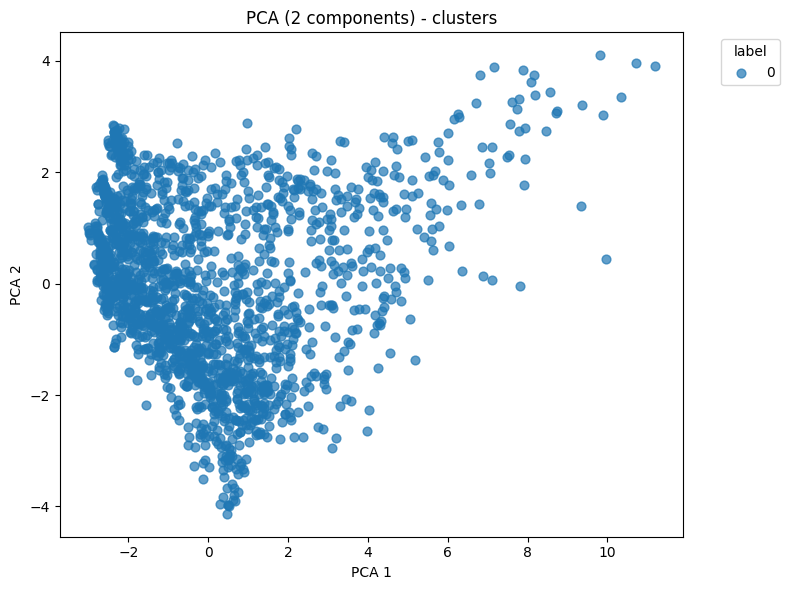

In [14]:
visualize_clusters(X_scaled, [0] * len(X_scaled))

In [17]:
from mpl_toolkits.mplot3d import Axes3D

def visualize_clusters_3d(X, labels, n_views=4, figsize=(16, 12),
                          title='3D PCA - Cluster visualization', elev=20):
    pca = PCA(n_components=3, random_state=13)
    X_pca = pca.fit_transform(X)
    
    labels = np.array(labels)
    unique_labels = np.unique(labels)
    
    n_cols = 2
    n_rows = int(np.ceil(n_views / n_cols))
    fig = plt.figure(figsize=figsize)

    for i, azim in enumerate(np.linspace(0, 360, n_views)):
        ax = fig.add_subplot(n_rows, n_cols, i + 1, projection='3d')
        for lab in unique_labels:
            mask = labels == lab
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1], X_pca[mask, 2],
                       label=str(lab), s=30, alpha=0.7)
        ax.view_init(elev=elev, azim=azim)
        ax.set_xlabel("PCA 1")
        ax.set_ylabel("PCA 2")
        ax.set_zlabel("PCA 3")
        if i == 0:
            ax.legend(title='Cluster')

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

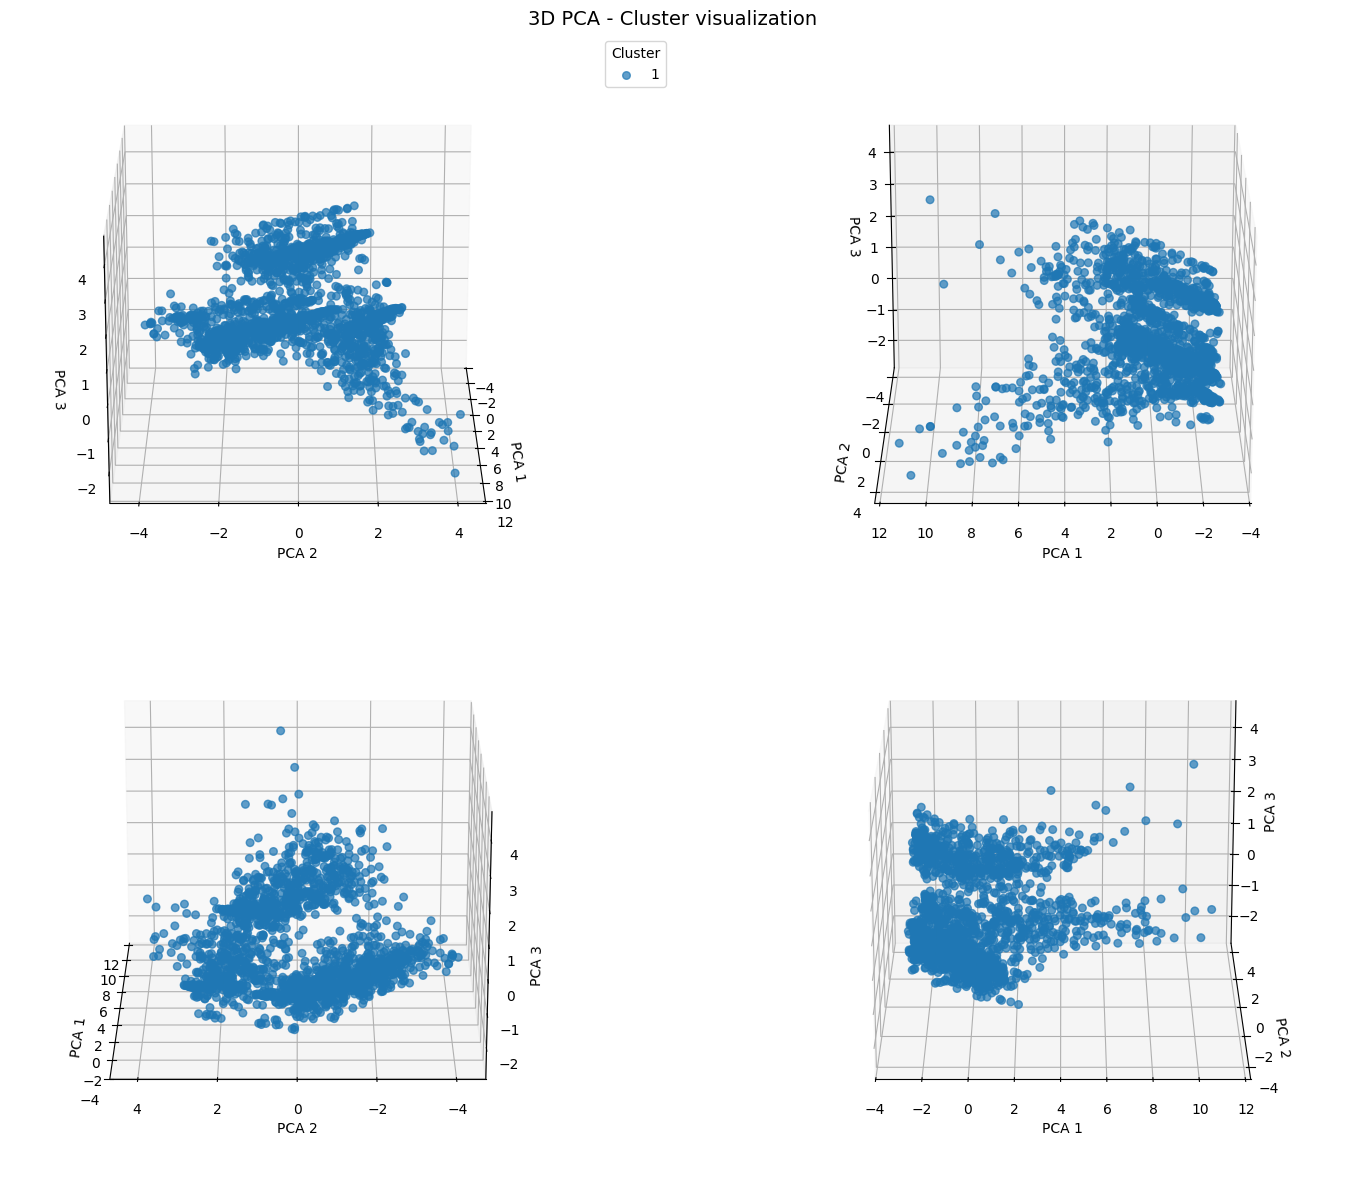

In [18]:
visualize_clusters_3d(X_scaled, [1] * len(X_scaled))

Даже глазом видно какие-то отдельные скопления

### Бейзлайн - разделение по странам

In [19]:
from sklearn.metrics import silhouette_score

In [50]:
silhouette_score(X_scaled, nations)

0.281010265437114

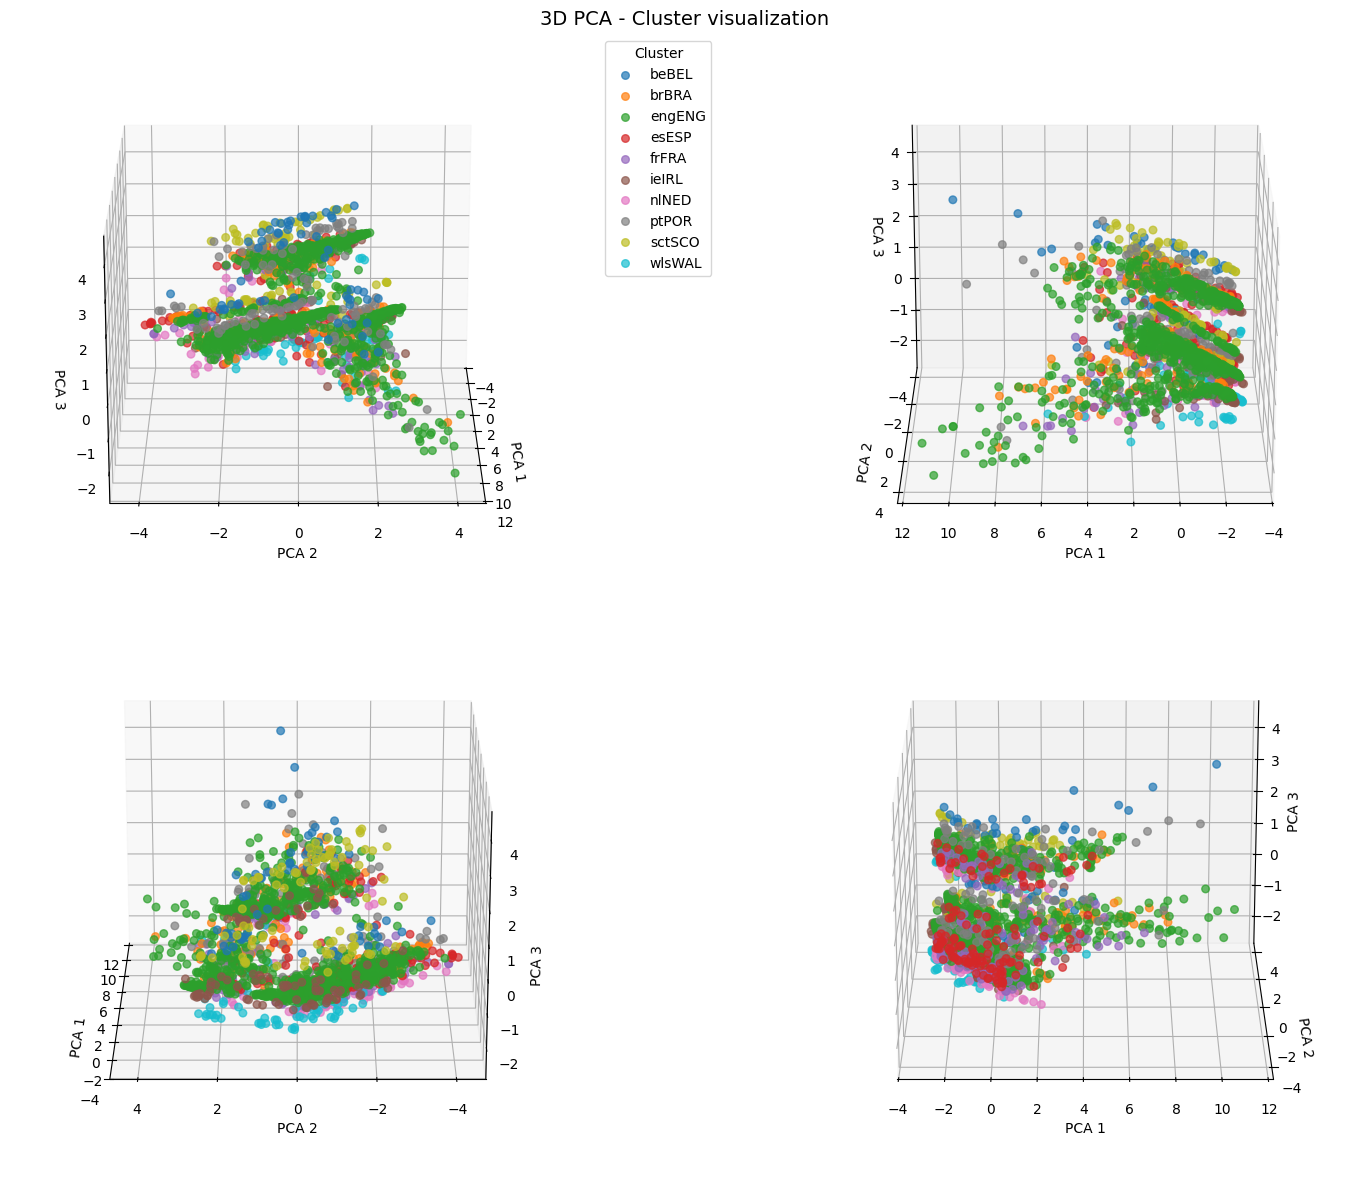

In [48]:
visualize_clusters_3d(X_scaled, nations)

In [66]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=8)
labels = kmeans.fit_predict(X_scaled)
silhouette_score(X_scaled, labels)

0.20209942616004334

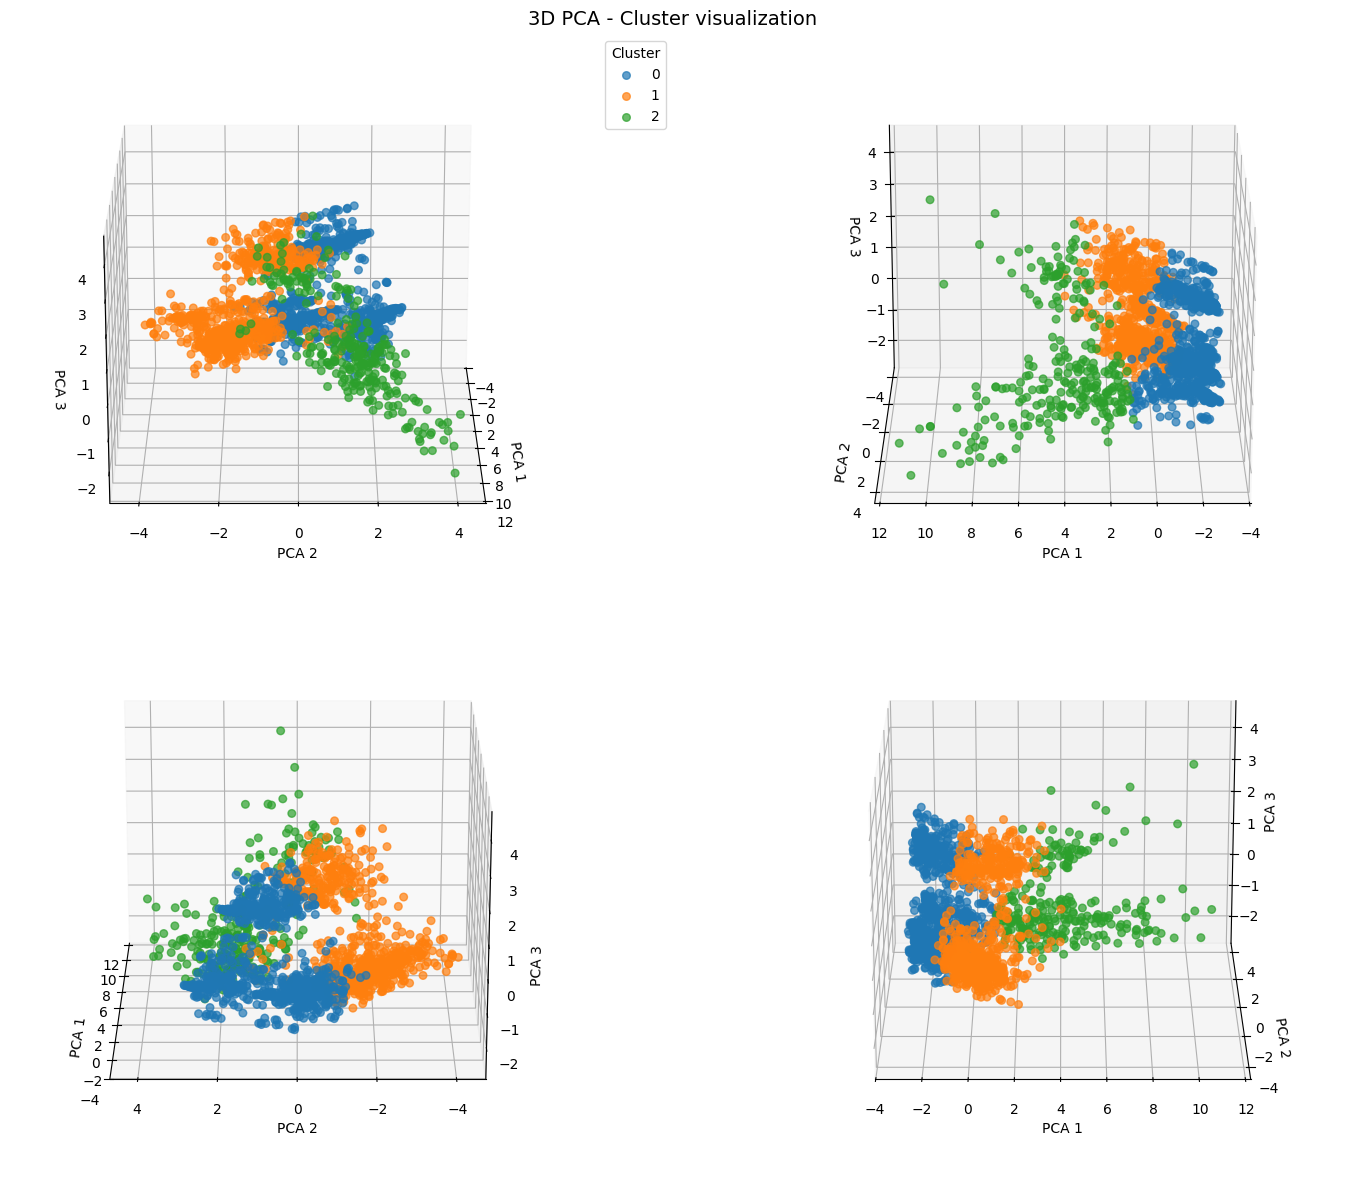

In [34]:
visualize_clusters_3d(X_scaled, labels)

Разделение по странам показывает себя лучше случайно взятого KMeans

### Оптимизация гиперпараметров

In [52]:
import optuna


def objective(trial):
    n_clusters = trial.suggest_int("n_clusters", 2, 25)
    max_iter = trial.suggest_int("max_iter", 100, 1000, step=50)
    tol = trial.suggest_float("tol", 1e-5, 1e-2, log=True)
    
    kmeans = KMeans(
        n_clusters=n_clusters,
        max_iter=max_iter,
        tol=tol,
        n_init=10,
        random_state=+18
    )
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    return score

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=+18))
study.optimize(objective, n_trials=300, show_progress_bar=True)

best_params = study.best_params
best_score = study.best_value

[I 2025-11-15 19:23:31,753] A new study created in memory with name: no-name-84cd34d7-7485-4a29-91da-52baf07b626e


  0%|          | 0/300 [00:00<?, ?it/s]

[I 2025-11-15 19:23:31,967] Trial 0 finished with value: 0.3870271344219072 and parameters: {'n_clusters': 17, 'max_iter': 550, 'tol': 0.0043231908958172366}. Best is trial 0 with value: 0.3870271344219072.
[I 2025-11-15 19:23:32,076] Trial 1 finished with value: 0.2659523122409343 and parameters: {'n_clusters': 6, 'max_iter': 900, 'tol': 0.001779954325808724}. Best is trial 0 with value: 0.3870271344219072.
[I 2025-11-15 19:23:32,209] Trial 2 finished with value: 0.38695946706215656 and parameters: {'n_clusters': 17, 'max_iter': 1000, 'tol': 5.9007235428457e-05}. Best is trial 0 with value: 0.3870271344219072.
[I 2025-11-15 19:23:32,294] Trial 3 finished with value: 0.2324725880723164 and parameters: {'n_clusters': 2, 'max_iter': 700, 'tol': 0.0034828691817978662}. Best is trial 0 with value: 0.3870271344219072.
[I 2025-11-15 19:23:32,440] Trial 4 finished with value: 0.38779305064200054 and parameters: {'n_clusters': 19, 'max_iter': 100, 'tol': 2.1617695339723554e-05}. Best is trial 

По логам видно, что на результат влияет только n_clusters

In [53]:
best_params

{'n_clusters': 24, 'max_iter': 150, 'tol': 0.0006008378522987495}

Т.к. KMeans уже занято, возьму следующую по алфавиту букву

In [54]:
import numpy as np
from sklearn.base import BaseEstimator

class LMeans(BaseEstimator):
    def __init__(self, n_clusters=14, n_init=10, max_iter=400, tol=1e-4, random_state=None):
        self.n_clusters = n_clusters
        self.n_init = n_init
        self.max_iter = max_iter
        self.tolerance = tol
        self.random_state = random_state

        self.inertia_ = np.inf
        self.centroids_ = None
        self.labels_ = None

    def _init_centroids(self, X: np.array):
        indices = self.rng.choice(X.shape[0], self.n_clusters, replace=False)
        return X[indices]

    def _compute_distances(self, X, centroids):
        return np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)

    def _get_clusters(self, distances):
        return np.argmin(distances, axis=1)

    def _update_centroids(self, X, labels):
        new_centroids = np.zeros((self.n_clusters, X.shape[1]))
        for k in range(self.n_clusters):
            cluster_points = X[labels == k]
            if len(cluster_points) > 0:
                new_centroids[k] = cluster_points.mean(axis=0)
            else:
                new_centroids[k] = X[np.random.randint(0, X.shape[0])]
        return new_centroids

    def fit(self, X):
        self.rng = np.random.default_rng(self.random_state)
        X = np.asarray(X)
        
        self.inertia_ = np.inf
        self.centroids_ = None
        self.labels_ = None
        for _ in range(self.n_init):
            centroids = self._init_centroids(X)
            
            for i in range(self.max_iter):
                distances = self._compute_distances(X, centroids)
                labels = self._get_clusters(distances)
                new_centroids = self._update_centroids(X, labels)
                
                shift = np.linalg.norm(centroids - new_centroids)
                centroids = new_centroids
                if shift < self.tolerance:
                    break
            inertia = np.sum((X - centroids[labels])**2)
            if inertia < self.inertia_:
                self.inertia_ = inertia
                self.centroids_ = centroids
                self.labels_ = labels

    def predict(self, X):
        distances = self._compute_distances(X, self.centroids_)
        return np.argmin(distances, axis=1)

    def fit_predict(self, X):
        self.fit(X)
        return self.predict(X)

In [55]:
def objective(trial):
    n_clusters = trial.suggest_int("n_clusters", 2, 25)
    max_iter = trial.suggest_int("max_iter", 100, 1000, step=50)
    tol = trial.suggest_float("tol", 1e-5, 1e-2, log=True)
    
    lmeans = LMeans(
        n_clusters=n_clusters,
        max_iter=max_iter,
        tol=tol,
        random_state=13
    )
    labels = lmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=300, show_progress_bar=True)

best_params = study.best_params
best_score = study.best_value

[I 2025-11-15 19:24:21,920] A new study created in memory with name: no-name-56e87a6f-f271-49e3-b8cf-f4046aee46f3


  0%|          | 0/300 [00:00<?, ?it/s]

[I 2025-11-15 19:24:22,854] Trial 0 finished with value: 0.35398050981398527 and parameters: {'n_clusters': 21, 'max_iter': 300, 'tol': 0.0004730797868782563}. Best is trial 0 with value: 0.35398050981398527.
[I 2025-11-15 19:24:23,520] Trial 1 finished with value: 0.38206776547949983 and parameters: {'n_clusters': 17, 'max_iter': 500, 'tol': 0.0003196590636692048}. Best is trial 1 with value: 0.38206776547949983.
[I 2025-11-15 19:24:23,787] Trial 2 finished with value: 0.29016577665503673 and parameters: {'n_clusters': 8, 'max_iter': 650, 'tol': 0.0003330011843169615}. Best is trial 1 with value: 0.38206776547949983.
[I 2025-11-15 19:24:24,377] Trial 3 finished with value: 0.32733930312593995 and parameters: {'n_clusters': 13, 'max_iter': 450, 'tol': 0.0002280742862478487}. Best is trial 1 with value: 0.38206776547949983.
[I 2025-11-15 19:24:25,549] Trial 4 finished with value: 0.3343022538903505 and parameters: {'n_clusters': 16, 'max_iter': 800, 'tol': 2.1710965963827786e-05}. Best 

In [56]:
best_params

{'n_clusters': 24, 'max_iter': 450, 'tol': 0.00047238704560556295}

### Сравнение

In [60]:
cluster_range = range(2, 25)

k_inertia = []
l_inertia = []
k_sil = []
l_sil = []

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=13)
    k_labels = kmeans.fit_predict(X_scaled)

    k_inertia.append(kmeans.inertia_)
    k_sil.append(silhouette_score(X_scaled, k_labels) * 1.5)

    lmeans = LMeans(n_clusters=k, random_state=13)
    l_labels = lmeans.fit_predict(X_scaled)
    l_sil.append(silhouette_score(X_scaled, l_labels) * 1.5)

    l_inertia.append(lmeans.inertia_)

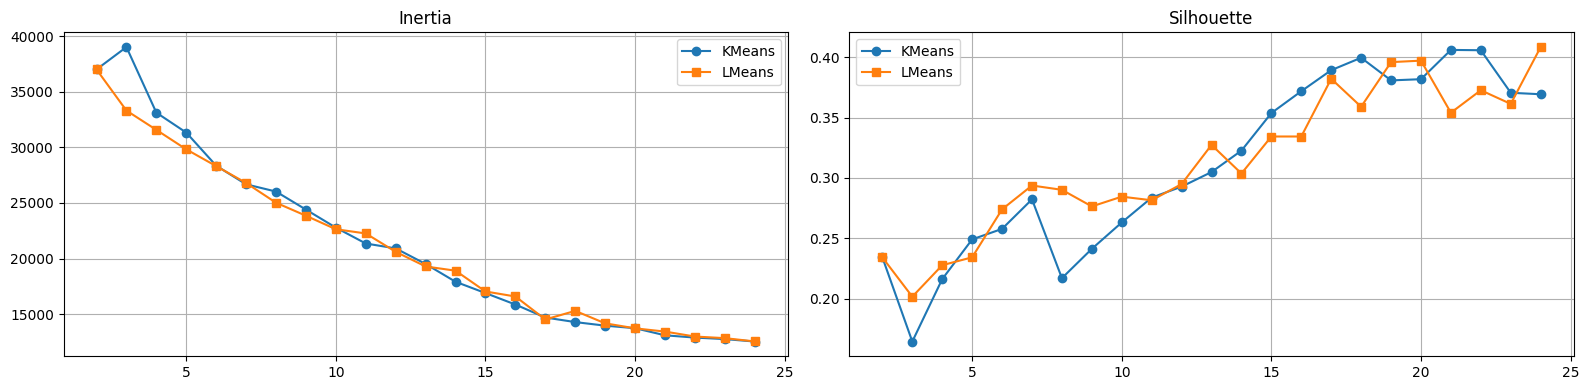

In [63]:
plt.figure(figsize=(16, 4))

plt.subplot(1, 2, 1)
plt.plot(cluster_range, k_inertia, marker="o", label="KMeans")
plt.plot(cluster_range, l_inertia, marker="s", label="LMeans")
plt.title("Inertia")
plt.grid(True)
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(cluster_range, k_sil, marker="o", label="KMeans")
plt.plot(cluster_range, l_sil, marker="s", label="LMeans")
plt.title("Silhouette")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


Примерно на 20 начинается плато

In [62]:
kmeans = KMeans(n_clusters=20, random_state=13)
k_labels = kmeans.fit_predict(X_scaled)

lmeans = LMeans(n_clusters=20, random_state=13)
l_labels = lmeans.fit_predict(X_scaled)



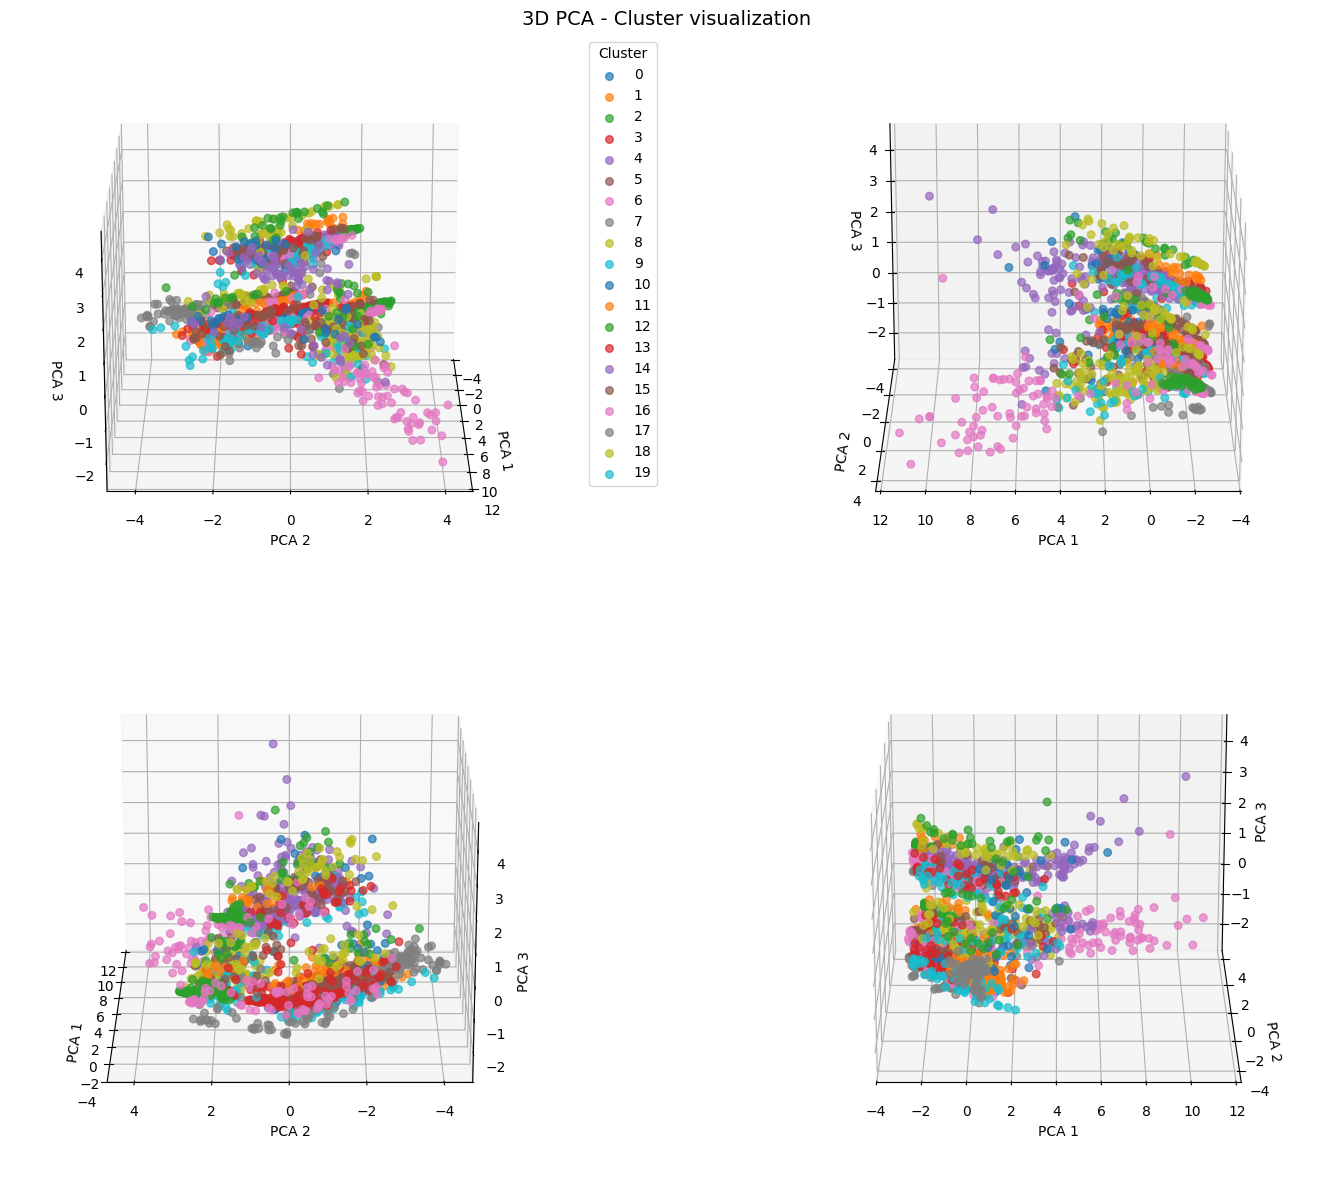

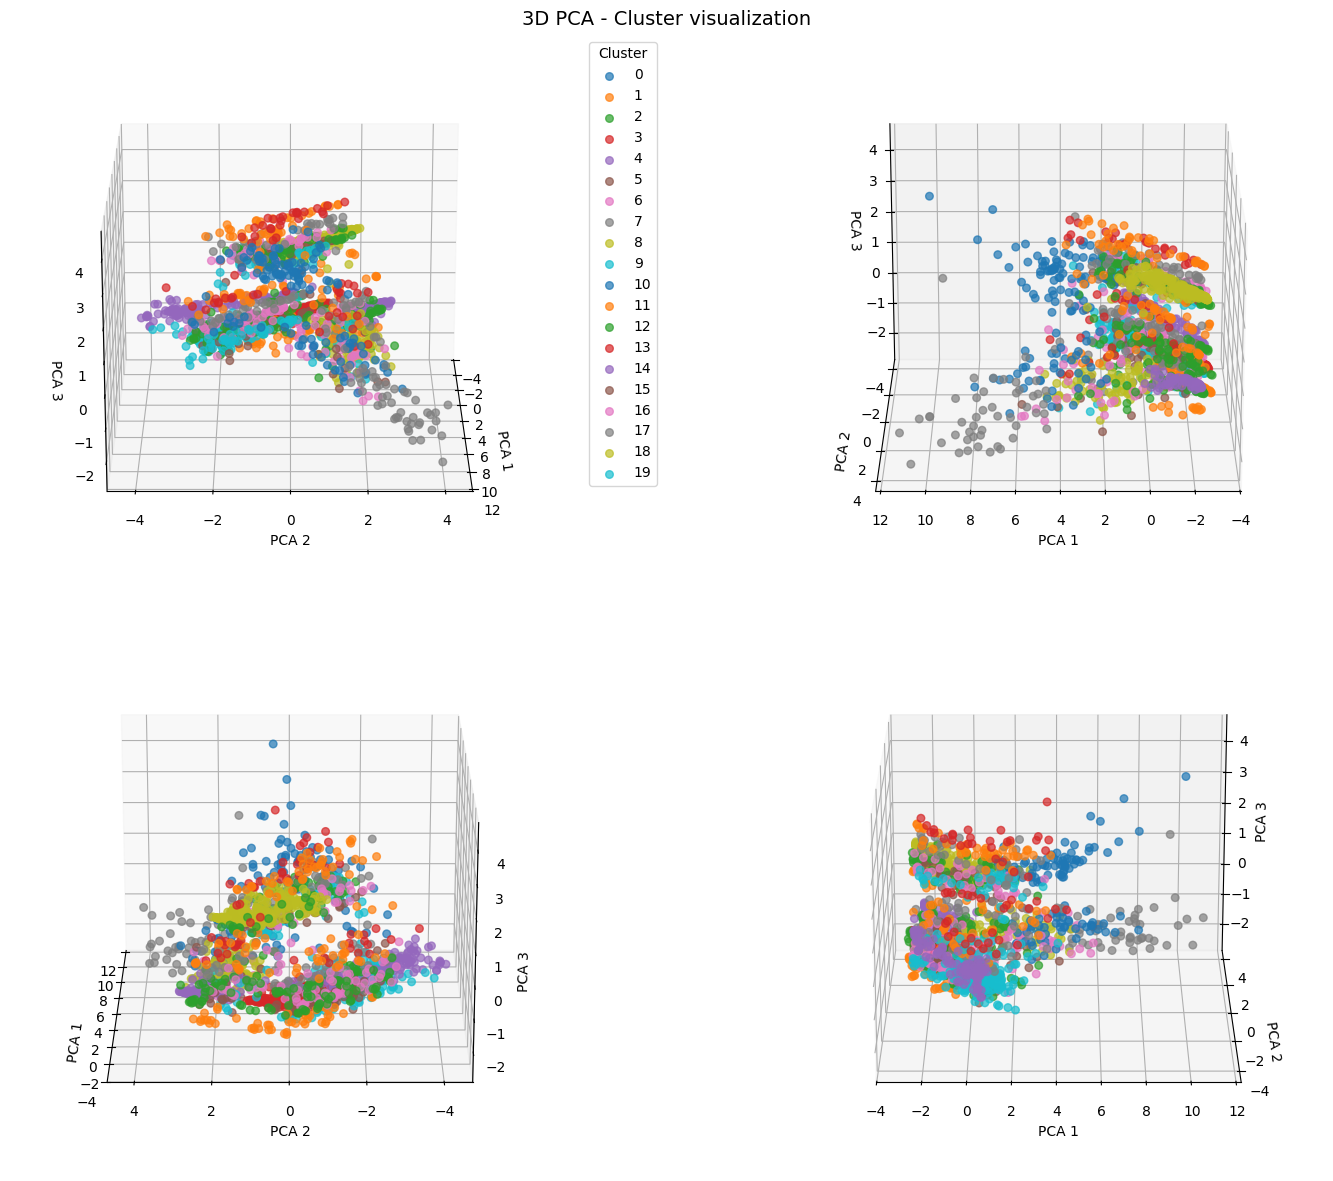

In [64]:
visualize_clusters_3d(X_scaled, k_labels)

visualize_clusters_3d(X_scaled, l_labels)

Разделение получилось похожим, хоть и немного разным. Метрики тоже близкие